In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
conda install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 4.202 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.5   pyh5ded981_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [5]:
conda install matplotlib

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.804 seconds
All requested packages already installed.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
conda install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.845 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.27.0     pyh5ded981_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools        

In [8]:
conda install imbalanced-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, imbalanced-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.817 seconds
  Name              Version  Build         Channel
--------------------------------------------------------
+ imbalanced-learn  0.14.2   pyhd8ed1ab_0  conda-forge
+ sklearn-compat    0.1.6    pyhd8ed1ab_0  conda-forge


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.metrics import (precision_score,recall_score,f1_score,roc_auc_score,classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

In [11]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [12]:
df = pd.read_csv('fraud_dataset.csv')

In [18]:
df['IsFraud']=(df['TotalPriceDiff']!=0).astype(int)
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,ReferralSource,TotalPrice,OrderYear,OrderMonth,OrderDay,IsWeekend,CalculatedTotal,TotalPriceDiff,CouponUsed,IsFraud
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,Instagram,2853.10,2023,January,Wednesday,False,2853.10,0.000000e+00,True,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,Referral,302.70,2024,August,Friday,False,302.70,0.000000e+00,True,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,Email,2753.40,2024,February,Tuesday,False,2753.40,4.547474e-13,True,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,Facebook,273.19,2023,October,Sunday,True,273.19,0.000000e+00,True,0
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,Email,2504.04,2025,May,Thursday,False,2504.04,0.000000e+00,True,0
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,...,Instagram,491.72,2023,October,Monday,False,491.72,0.000000e+00,True,0
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,...,Facebook,664.42,2025,June,Tuesday,False,664.42,0.000000e+00,True,0
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,...,Facebook,747.75,2023,May,Friday,False,747.75,0.000000e+00,True,0
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,...,Email,268.56,2025,April,Wednesday,False,268.56,0.000000e+00,True,0
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,...,Google,2037.52,2023,November,Tuesday,False,2037.52,0.000000e+00,True,0


In [22]:
df.dtypes

OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
OrderYear            int64
OrderMonth             str
OrderDay               str
IsWeekend             bool
CalculatedTotal    float64
TotalPriceDiff     float64
CouponUsed            bool
IsFraud              int32
dtype: object

In [26]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])
print("Missing values :",df.isnull().sum().sum())
print("Duplicate records :",df.duplicated().sum())
print("Fraud records :",df['IsFraud'].sum())
print("Non-fraud records :",(df['IsFraud']==0).sum())

Rows : 1200
Columns : 22
Missing values : 0
Duplicate records : 0
Fraud records : 134
Non-fraud records : 1066


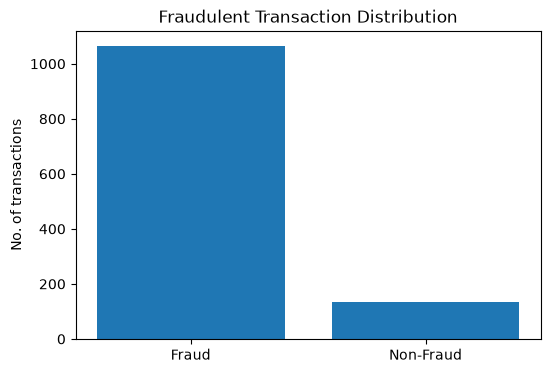

Imbalance ratio (Fraud:Non-Fraud)
7.96 : 1


In [28]:
count_by_class=df['IsFraud'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(['Fraud','Non-Fraud'],count_by_class.values)
plt.ylabel('No. of transactions')
plt.title('Fraudulent Transaction Distribution')
plt.show()

print("Imbalance ratio (Fraud:Non-Fraud)")
print(round(count_by_class.get(0,0)/max(count_by_class.get(1,0),1),2),": 1")

In [29]:
features=['Product','Quantity',
          'UnitPrice','PaymentMethod',
          'ItemsInCart','CouponCode',
          'ReferralSource','TotalPrice',
          'CouponUsed','OrderMonth',
          'OrderYear','OrderDay']
target='IsFraud'
X=df[features].copy()
y=df[target].copy()

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("\nTraining target distribution")
print("IsFraud=0\n",(y_train==0).sum())
print("IsFraud=0\n",(y_train!=0).sum())
print("\nTest target distribution")
print("IsFraud=0\n",(y_test==0).sum())
print("IsFraud=0\n",(y_test!=0).sum())

Training rows: 960
Test rows: 240

Training target distribution
IsFraud=0
 853
IsFraud=0
 107

Test target distribution
IsFraud=0
 213
IsFraud=0
 27


In [45]:
cat_feat=["Product","PaymentMethod","CouponCode","ReferralSource"]
num_feat=["Quantity","UnitPrice","ItemsInCart","TotalPrice","CouponUsed","OrderYear"]
numeric_transformer = SklearnPipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                             ("scaler", StandardScaler())])

categorical_transformer = SklearnPipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                                 ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, num_feat),
        ("cat", categorical_transformer, cat_feat)])

print("Numeric features:", num_feat)
print("Categorical features:", cat_feat)

Numeric features: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'CouponUsed', 'OrderYear']
Categorical features: ['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']


In [46]:
lr_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight=None,
        random_state=42))])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_metrics = {
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, lr_pred, zero_division=0),
    "Recall": recall_score(y_test, lr_pred, zero_division=0),
    "F1": f1_score(y_test, lr_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lr_prob)}

pd.DataFrame([lr_metrics])

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.149425,0.481481,0.22807,0.593984


In [49]:
rf_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1))])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_metrics = {
    "Model": "Random Forest",
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1": f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

pd.DataFrame([rf_metrics])

,Model,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.214286,0.111111,0.146341,0.791688


In [50]:
results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("Model")
display(results.round(4))
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, digits=4, zero_division=0))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred, digits=4, zero_division=0))

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.1494,0.4815,0.2281,0.5940
Random Forest,0.2143,0.1111,0.1463,0.7917


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9085    0.6526    0.7596       213
           1     0.1494    0.4815    0.2281        27

    accuracy                         0.6333       240
   macro avg     0.5290    0.5670    0.4938       240
weighted avg     0.8231    0.6333    0.6998       240


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.8938    0.9484    0.9203       213
           1     0.2143    0.1111    0.1463        27

    accuracy                         0.8542       240
   macro avg     0.5540    0.5297    0.5333       240
weighted avg     0.8174    0.8542    0.8332       240



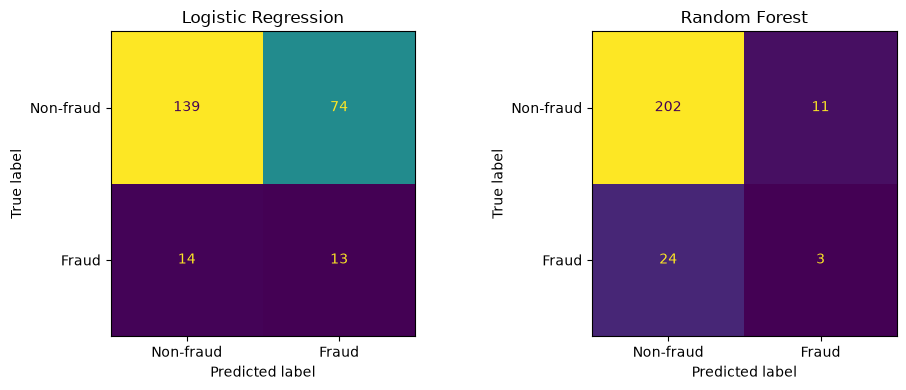

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_pred),
    display_labels=["Non-fraud", "Fraud"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=["Non-fraud", "Fraud"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

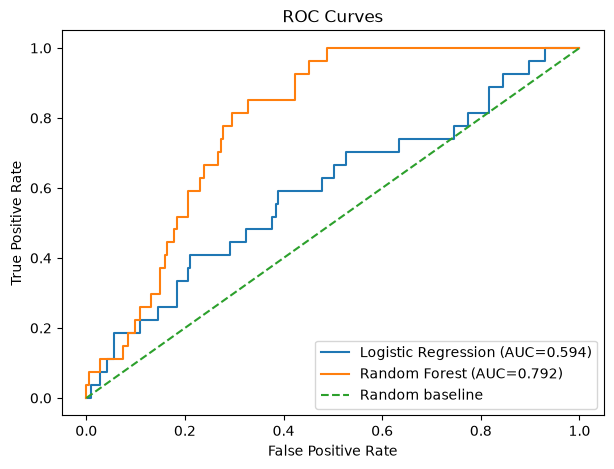

In [52]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_metrics['ROC-AUC']:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [53]:
def threshold_table(y_true, probabilities, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for threshold in thresholds:
        pred = (probabilities >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

lr_thresholds = threshold_table(y_test, lr_prob)
rf_thresholds = threshold_table(y_test, rf_prob)

print("Logistic Regression threshold analysis")
display(lr_thresholds.round(3))

print("Random Forest threshold analysis")
display(rf_thresholds.round(3))

Logistic Regression threshold analysis


,Threshold,Precision,Recall,F1
0,0.10,0.119,1.000,0.213
1,0.15,0.116,0.926,0.207
2,0.20,0.116,0.815,0.203
3,0.25,0.112,0.741,0.194
4,0.30,0.127,0.741,0.217
5,0.35,0.138,0.704,0.230
6,0.40,0.143,0.630,0.233
7,0.45,0.162,0.593,0.254
8,0.50,0.149,0.481,0.228
9,0.55,0.155,0.407,0.224


Random Forest threshold analysis


,Threshold,Precision,Recall,F1
0,0.10,0.204,0.852,0.329
1,0.15,0.242,0.815,0.373
2,0.20,0.240,0.667,0.353
3,0.25,0.262,0.593,0.364
4,0.30,0.250,0.444,0.320
5,0.35,0.216,0.296,0.250
6,0.40,0.222,0.222,0.222
7,0.45,0.217,0.185,0.200
8,0.50,0.214,0.111,0.146
9,0.55,0.300,0.111,0.162


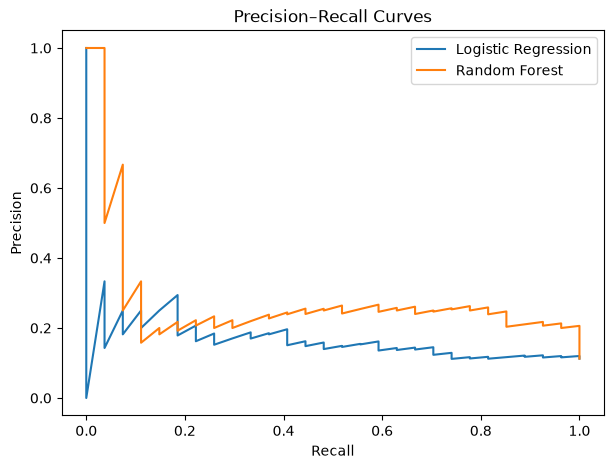

In [54]:
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()

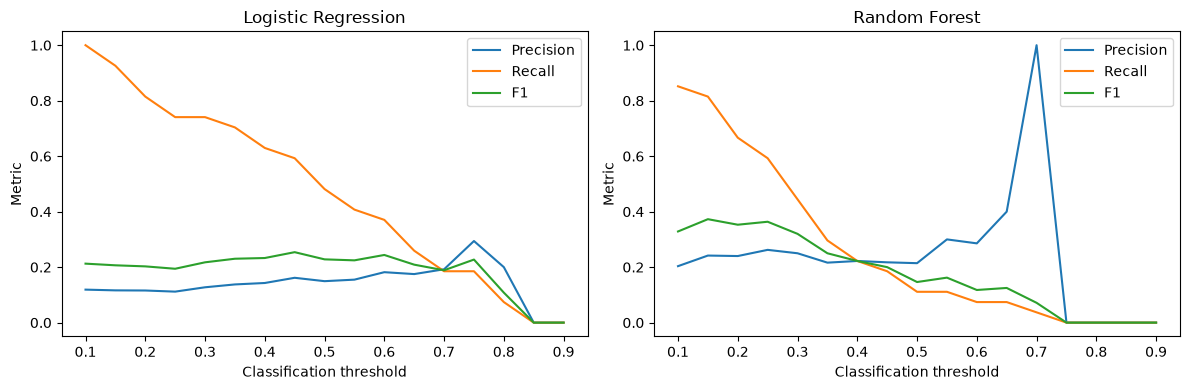

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for table, name, ax in [
    (lr_thresholds, "Logistic Regression", axes[0]),
    (rf_thresholds, "Random Forest", axes[1])
]:
    ax.plot(table["Threshold"], table["Precision"], label="Precision")
    ax.plot(table["Threshold"], table["Recall"], label="Recall")
    ax.plot(table["Threshold"], table["F1"], label="F1")
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel("Metric")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

,Feature,Importance
0,num__Quantity,0.311246
2,num__ItemsInCart,0.068767
3,num__TotalPrice,0.067298
5,num__OrderYear,0.059798
23,cat__ReferralSource_Facebook,0.057809
1,num__UnitPrice,0.047862
10,cat__Product_Phone,0.027107
17,cat__PaymentMethod_Online,0.026643
13,cat__PaymentMethod_Cash,0.026093
25,cat__ReferralSource_Instagram,0.025096


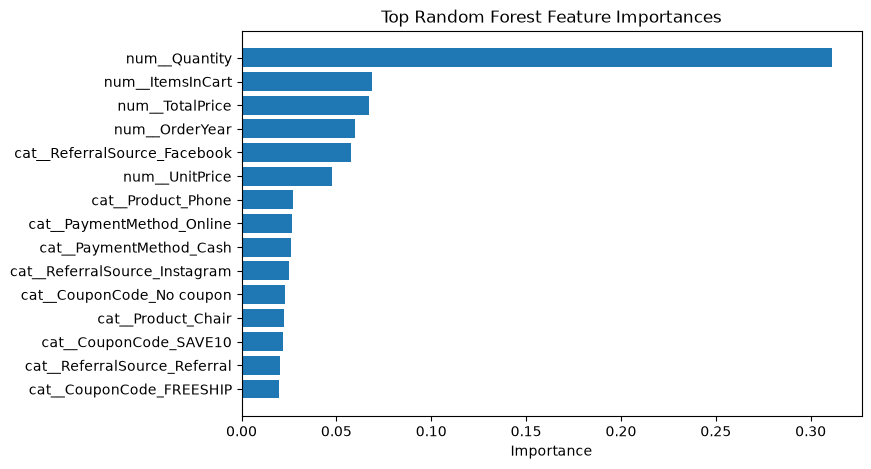

In [56]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.show()

In [57]:
df.to_csv("clustered_dataset.csv")
print("Final dataset saved as clustered_dataset.csv")

Final dataset saved as clustered_dataset.csv
